# 🤖 Machine Learning — Partie 3
## Introduction au Deep Learning & NLP

---

### 📋 Sommaire
1. 📦 Imports
2. 🔤 Préparation des données texte
3. 🧠 Réseaux Neuronaux
4. 💬 ML et NLP — Traitement Automatique des Langues (TAL)
5. ✅ Conclusion

## 📦 1. Imports

In [1]:
# ──────────────────────────────────────────────────
# AFFICHAGE DYNAMIQUE
# ──────────────────────────────────────────────────
from IPython.display import Markdown, display   # Affichage markdown dynamique dans les cellules

# ──────────────────────────────────────────────────
# MANIPULATION DE DONNÉES
# ──────────────────────────────────────────────────
import numpy as np                               # Calculs numériques, tableaux
import pandas as pd                              # Manipulation de DataFrames

# ──────────────────────────────────────────────────
# VISUALISATION
# ──────────────────────────────────────────────────
import matplotlib.pyplot as plt                  # Graphiques et courbes
import matplotlib.patches as mpatches           # Patches pour les légendes personnalisées

# ──────────────────────────────────────────────────
# NLP — NLTK
# ──────────────────────────────────────────────────
import nltk                                      # Natural Language Toolkit
from nltk.corpus import stopwords               # Mots vides (le, la, les, et...)
from nltk.tokenize import word_tokenize         # Découpage en tokens (mots)
from nltk.stem import PorterStemmer            # Stemmatisation (radical des mots)
from nltk.stem import WordNetLemmatizer        # Lemmatisation (forme canonique)

# Téléchargement des ressources NLTK nécessaires
nltk.download('punkt',      quiet=True)         # Modèle de tokenisation
nltk.download('punkt_tab',  quiet=True)         # Données punkt pour word_tokenize
nltk.download('stopwords',  quiet=True)         # Liste de mots vides
nltk.download('wordnet',    quiet=True)         # Base de données pour lemmatisation
nltk.download('averaged_perceptron_tagger', quiet=True)  # Modèle POS tagging
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

# ──────────────────────────────────────────────────
# NLP — SCIKIT-LEARN
# ──────────────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer  # Vectorisation TF-IDF

# ──────────────────────────────────────────────────
# CONSTANTES GLOBALES DU PROJET
# ──────────────────────────────────────────────────
VOCAB_SIZE    = 10000  # Taille du vocabulaire (nombre de mots uniques retenus)
MAX_LEN       = 200    # Longueur maximale des séquences (en tokens)
EMBEDDING_DIM = 64     # Dimension des vecteurs d'embedding

print("✅ Imports et constantes chargés avec succès")
display(Markdown(f"""
| Constante | Valeur |
|-----------|--------|
| VOCAB_SIZE | `{VOCAB_SIZE}` |
| MAX_LEN | `{MAX_LEN}` |
| EMBEDDING_DIM | `{EMBEDDING_DIM}` |
"""))

✅ Imports et constantes chargés avec succès



| Constante | Valeur |
|-----------|--------|
| VOCAB_SIZE | `10000` |
| MAX_LEN | `200` |
| EMBEDDING_DIM | `64` |


---
## 🔤 2. Préparation des données texte

### 2.1 Pourquoi transformer le texte en nombres ?

Un algorithme de Machine Learning ne comprend **que des nombres**.  
Il est donc impossible de lui donner directement du texte brut comme `"Le chat mange"`.  

Il faut donc **convertir** chaque mot (ou phrase) en un vecteur numérique.  
Il existe plusieurs façons de faire ça, avec des compromis différents :

| Méthode | Type | Avantage | Inconvénient |
|---------|------|----------|--------------|
| One-Hot Encoding | Sparse | Simple, universel | Pas de sens sémantique, vecteurs gigantesques |
| TF-IDF | Sparse | Pondération intelligente | Toujours pas de contexte |
| Word Embeddings | Dense | Capture le sens, contexte | Besoin de données ou modèle pré-entraîné |

> 💡 **Sparse** = la majorité du vecteur est remplie de `0`  
> 💡 **Dense** = chaque dimension contient une valeur utile (ex: `[1.2, -0.1, 4.3, 3.2]`)

### 2.2 Tokenization

La **tokenization** consiste à **découper** un texte en unités élémentaires appelées **tokens**.  
Un token peut être :
- un **mot** : `"Le chien mange"` → `['Le', 'chien', 'mange']`
- un **caractère** : `['L', 'e', ' ', 'c', ...]`
- un **sous-mot** (subword) : utilisé dans les LLMs modernes

C'est la **première étape** de tout pipeline NLP.  
Sans tokenization, impossible de transformer un texte en vecteur.

In [2]:
# ── Exemple de tokenization avec NLTK ──────────────────────────────────────

texte = "Le chien mange vite. Il aime les croquettes !"

# word_tokenize découpe en tokens (mots + ponctuation)
tokens = word_tokenize(texte, language='french')

display(Markdown(f"**Texte original :** `{texte}`"))
display(Markdown(f"**Tokens obtenus :** `{tokens}`"))
display(Markdown(f"**Nombre de tokens :** `{len(tokens)}`"))

**Texte original :** `Le chien mange vite. Il aime les croquettes !`

**Tokens obtenus :** `['Le', 'chien', 'mange', 'vite', '.', 'Il', 'aime', 'les', 'croquettes', '!']`

**Nombre de tokens :** `10`

📌 Ce que j'observe

La tokenization découpe bien la phrase en mots individuels.  
La ponctuation (`!`, `.`) devient elle aussi un token séparé.  
Ce sont ces tokens qu'on va ensuite convertir en nombres.

### 2.3 Sparse Vectors & One-Hot Encoding

Le **One-Hot Encoding** est la méthode la plus simple pour représenter un mot.  

**Principe :**
- On constitue un vocabulaire de tous les mots connus → ex: `['cat', 'mat', 'on', 'sat', 'the']`
- Chaque mot est représenté par un vecteur de la **taille du vocabulaire**
- Le vecteur contient `0` partout, sauf `1` à la position du mot

```
Vocabulaire : ['cat', 'mat', 'on', 'sat', 'the']
                  0      1     2     3      4

  the  →  [0, 0, 0, 0, 1]
  cat  →  [1, 0, 0, 0, 0]
  sat  →  [0, 0, 0, 1, 0]
```

**Problème :** Si le vocabulaire contient 50 000 mots, chaque vecteur a 50 000 dimensions dont 49 999 à `0`.  
C'est ce qu'on appelle un vecteur **Sparse** (creux). Très coûteux en mémoire !

Vocabulaire : ['cat', 'mat', 'on', 'sat', 'the']
Taille du vecteur : 5

  the    → [0, 0, 0, 0, 1]
  cat    → [1, 0, 0, 0, 0]
  sat    → [0, 0, 0, 1, 0]
  mat    → [0, 1, 0, 0, 0]


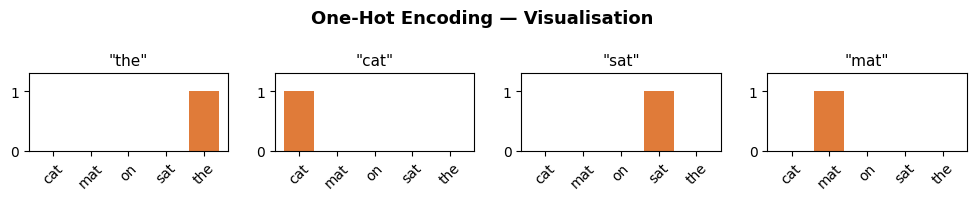

In [3]:
# ── Démonstration One-Hot Encoding manuel ──────────────────────────────────

vocabulaire = ['cat', 'mat', 'on', 'sat', 'the']

def one_hot_encode(mot, vocab):
    """Retourne le vecteur one-hot d'un mot par rapport à un vocabulaire."""
    vecteur = [0] * len(vocab)          # Vecteur de 0 de la taille du vocabulaire
    if mot in vocab:
        vecteur[vocab.index(mot)] = 1   # On met 1 à la position du mot
    return vecteur

# Test sur plusieurs mots
mots_test = ['the', 'cat', 'sat', 'mat']

print(f"Vocabulaire : {vocabulaire}")
print(f"Taille du vecteur : {len(vocabulaire)}\n")

for mot in mots_test:
    vecteur = one_hot_encode(mot, vocabulaire)
    print(f"  {mot:6s} → {vecteur}")

# Visualisation graphique des vecteurs one-hot
fig, axes = plt.subplots(1, len(mots_test), figsize=(10, 2))
fig.suptitle("One-Hot Encoding — Visualisation", fontsize=13, fontweight='bold')

for i, mot in enumerate(mots_test):
    vecteur = one_hot_encode(mot, vocabulaire)
    axes[i].bar(vocabulaire, vecteur, color=['#e07b39' if v == 1 else '#cccccc' for v in vecteur])
    axes[i].set_title(f'"{mot}"', fontsize=11)
    axes[i].set_ylim(0, 1.3)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

📌 Ce que j'observe

Chaque mot produit un vecteur avec exactement **un seul `1`** et des `0` partout ailleurs.  
Sur un vocabulaire de 5 mots c'est gérable, mais avec 50 000 mots en réalité, c'est inefficace.  
De plus, `cat` et `sat` sont aussi "éloignés" mathématiquement que `cat` et `the` — aucun sens sémantique n'est capturé.

### 2.4 TF-IDF (Term Frequency – Inverse Document Frequency)

Le **TF-IDF** améliore le One-Hot en attribuant un **poids** à chaque mot selon son importance réelle.  

Il combine deux mesures :

| Mesure | Formule simplifiée | Signification |
|--------|-------------------|---------------|
| **TF** (Term Frequency) | `nb fois le mot dans le doc / nb total mots` | À quelle fréquence le mot apparaît dans CE document |
| **IDF** (Inverse Doc Frequency) | `log(nb docs total / nb docs contenant le mot)` | Ce mot est-il rare ou commun dans l'ensemble des documents ? |

**Score TF-IDF = TF × IDF**

> 💡 **Intuition :** Un mot comme "le" ou "la" apparaît dans TOUS les documents → IDF très bas → score TF-IDF proche de 0.  
> Un mot technique rare qui apparaît souvent dans un seul document → score élevé = très informatif !

**Quand l'utiliser ?**  
- Algorithmes ML classiques (SVM, Random Forest, Naive Bayes) pour la classification de texte  
- Recherche d'information, moteurs de recherche  
- Résumé automatique  

> ⚠️ TF-IDF reste un vecteur **Sparse** — il ne capture pas le contexte ni le sens des mots.

Vocabulaire appris (9 mots) :
  ['and', 'document', 'first', 'is', 'one', 'second', 'the', 'third', 'this']

Phrase 1 : 'I worked on my document'
  Vecteur : [0. 1. 0. 0. 0. 0. 0. 0. 0.]

Phrase 2 : 'I worked on my first document'
  Vecteur : [0.     0.6292 0.7772 0.     0.     0.     0.     0.     0.    ]


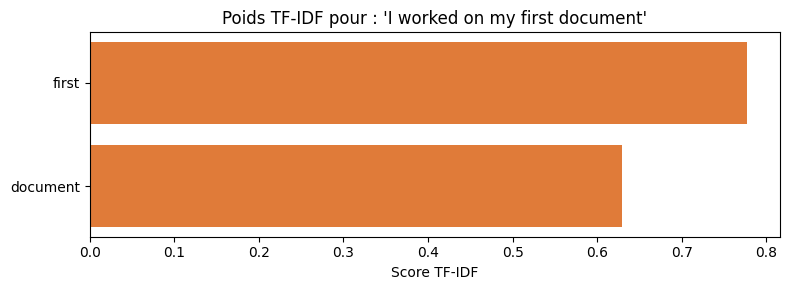

In [4]:
# ── Démonstration TF-IDF avec scikit-learn ─────────────────────────────────

# Notre "corpus" = ensemble de documents
corpus = [
    'This is the first document.',
    'This is the second document.',
    'and this is a third one',
    'Is this the first document?'
]

# Création et entraînement du vectoriseur TF-IDF sur le corpus
vectorizer = TfidfVectorizer()
X = vectorizer.fit(corpus)  # Le modèle apprend le vocabulaire

# Liste des mots appris dans le vocabulaire
feature_names = vectorizer.get_feature_names_out()
print(f"Vocabulaire appris ({len(feature_names)} mots) :")
print(f"  {list(feature_names)}\n")

# Transformation de nouvelles phrases
phrase1 = ['I worked on my document']
phrase2 = ['I worked on my first document']

vec1 = X.transform(phrase1).toarray()
vec2 = X.transform(phrase2).toarray()

print(f"Phrase 1 : '{phrase1[0]}'")
print(f"  Vecteur : {np.round(vec1[0], 4)}")

print(f"\nPhrase 2 : '{phrase2[0]}'")
print(f"  Vecteur : {np.round(vec2[0], 4)}")

# Visualisation des poids TF-IDF pour la phrase 2
scores = vec2[0]
mots_non_nuls = [(feature_names[i], scores[i]) for i in range(len(scores)) if scores[i] > 0]

fig, ax = plt.subplots(figsize=(8, 3))
ax.barh([m[0] for m in mots_non_nuls], [m[1] for m in mots_non_nuls], color='#e07b39')
ax.set_title(f"Poids TF-IDF pour : '{phrase2[0]}'", fontsize=12)
ax.set_xlabel("Score TF-IDF")
plt.tight_layout()
plt.show()

📌 Ce que j'observe

Le mot `"first"` a un score plus élevé que `"document"` car il est moins fréquent dans le corpus.  
Les mots très courants comme `"is"` ou `"this"` ont un score très faible (voire 0) : ils n'apportent pas d'information distinctive.  
C'est exactement le comportement attendu du TF-IDF : **récompenser les mots rares et informatifs**.

### 2.5 Dense Vectors & Word Embeddings

Les **Word Embeddings** représentent chaque mot par un vecteur **dense** (aucune valeur nulle).  
La grande révolution : **les mots proches sémantiquement ont des vecteurs proches mathématiquement !**

```
cat  →  [ 1.2, -0.1,  4.3,  3.2]   # Vecteur 4D
dog  →  [ 1.1, -0.2,  4.1,  3.0]   # Proche de cat ! (même famille : animaux)
car  →  [-2.3,  3.1, -0.9,  0.5]   # Loin de cat (famille différente : véhicule)
```

**Comment sont construits ces vecteurs ?**  
Ils sont appris sur de très grandes quantités de texte.  
L'idée fondamentale (**hypothèse distributionnelle**) : *"un mot est défini par les mots qui l'entourent"*.

**Deux façons d'obtenir des embeddings :**

| Méthode | Description |
|---------|-------------|
| **Pré-entraînés** | GloVe, Word2Vec, FastText, SpaCy — télécharger un modèle déjà entraîné |
| **Appris à la volée** | La couche `Embedding` de TensorFlow/Keras apprend pendant l'entraînement |

> 💡 **Propriété mathématique fascinante :**  
> `vecteur("roi") - vecteur("homme") + vecteur("femme") ≈ vecteur("reine")`  
> Les embeddings capturent des **relations sémantiques** et **analogies** !

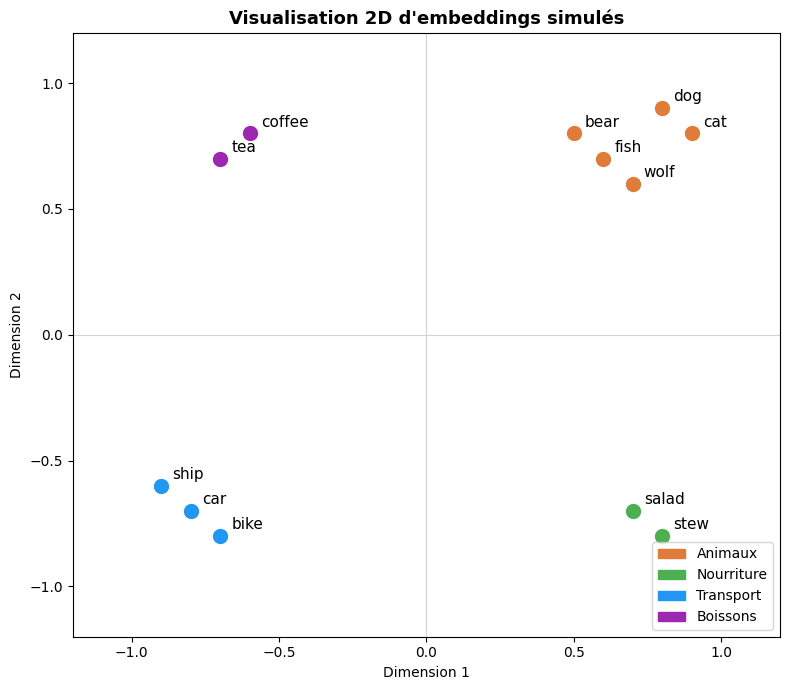

In [5]:
# ── Simulation d'embeddings 2D pour visualiser la proximité sémantique ─────
# (Valeurs fictives simplifiées pour illustrer le concept)

# Embeddings simulés en 2 dimensions (x, y)
embeddings_simules = {
    # Animaux
    'cat':    np.array([0.9,  0.8]),
    'dog':    np.array([0.8,  0.9]),
    'fish':   np.array([0.6,  0.7]),
    'wolf':   np.array([0.7,  0.6]),
    'bear':   np.array([0.5,  0.8]),
    # Nourriture
    'salad':  np.array([0.7,  -0.7]),
    'stew':   np.array([0.8,  -0.8]),
    # Transport
    'car':    np.array([-0.8, -0.7]),
    'bike':   np.array([-0.7, -0.8]),
    'ship':   np.array([-0.9, -0.6]),
    # Boissons
    'coffee': np.array([-0.6,  0.8]),
    'tea':    np.array([-0.7,  0.7]),
}

# Couleurs par groupe sémantique
groupes = {
    'Animaux':    (['cat', 'dog', 'fish', 'wolf', 'bear'],  '#e07b39'),
    'Nourriture': (['salad', 'stew'],                        '#4caf50'),
    'Transport':  (['car', 'bike', 'ship'],                  '#2196f3'),
    'Boissons':   (['coffee', 'tea'],                        '#9c27b0'),
}

fig, ax = plt.subplots(figsize=(8, 7))
ax.set_title("Visualisation 2D d'embeddings simulés", fontsize=13, fontweight='bold')
ax.axhline(0, color='lightgray', linewidth=0.8)
ax.axvline(0, color='lightgray', linewidth=0.8)

# Tracer chaque groupe
for label, (mots, couleur) in groupes.items():
    for mot in mots:
        x, y = embeddings_simules[mot]
        ax.scatter(x, y, color=couleur, s=100, zorder=5)
        ax.annotate(mot, (x, y), textcoords='offset points', xytext=(8, 5), fontsize=11)

# Légende
patches = [mpatches.Patch(color=c, label=l) for l, (_, c) in groupes.items()]
ax.legend(handles=patches, loc='lower right', fontsize=10)

ax.set_xlabel("Dimension 1")
ax.set_ylabel("Dimension 2")
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
plt.tight_layout()
plt.show()

📌 Ce que j'observe

Les mots du même groupe sémantique se regroupent dans la même zone du graphique.  
C'est exactement la propriété magique des embeddings : **la proximité géographique = proximité de sens**.  
Dans un vrai modèle, les vecteurs sont en 50, 100, 300 ou même 768 dimensions (BERT) — ici on simplifie à 2D pour visualiser.

### 2.6 Word Embeddings avec SpaCy

**SpaCy** est une bibliothèque NLP professionnelle qui fournit des modèles pré-entraînés incluant des embeddings.  

Elle peut être utilisée en combinaison avec **scikit-learn** pour alimenter des modèles ML classiques avec des vecteurs denses.

```bash
# Installation du modèle anglais (dans le terminal)
python -m spacy download en_core_web_lg
```

Le principe d'utilisation avec scikit-learn :

```python
import spacy

# Chargement du modèle SpaCy pré-entraîné
word_emb = spacy.load("en_core_web_lg")

# Transformation de phrases en vecteurs denses
sentences = [word_emb("The cat sat on the mat."),
             word_emb("The dog ate a croissant")]

# Réorganisation des vecteurs pour scikit-learn
sentence_list = [s.vector.reshape(1, -1) for s in sentences]  # Inversion des formes
input_data    = np.concatenate(sentence_list)                  # Matrice finale
```

> 💡 Chaque phrase devient un vecteur de **300 dimensions** (pour `en_core_web_lg`).  
> C'est la **moyenne des embeddings** de tous les mots de la phrase.

### 2.7 Quand utiliser quoi ? — Tableau de décision

Voici un guide pratique pour choisir la bonne méthode de vectorisation :

| Méthode | Type de modèle | Besoin d'ordre ? | Capture le sens ? | Taille des données |
|---------|---------------|-----------------|-------------------|-----------------|
| **One-Hot** | Réseaux complexes (LSTM, Transformer) | ✅ Oui | ❌ Non (le modèle apprend ensuite) | Petite → Grande |
| **TF-IDF** | ML classique (SVM, RF, NB) | ❌ Non | ❌ Non | Petite → Moyenne |
| **Embeddings pré-entraînés** (GloVe, SpaCy) | ML classique + Deep Learning | ✅ Oui | ✅ Oui | Toutes tailles |
| **Embeddings appris** (couche Keras) | Deep Learning | ✅ Oui | ✅ Oui (appris) | Moyenne → Grande |

**Règle mnémotechnique :**
- Algo ML classique (SVM, Random Forest) → **TF-IDF** ou **embeddings SpaCy**
- Réseau de neurones (LSTM, CNN texte) → **One-Hot + Embedding Keras** ou **embeddings pré-entraînés**

---
## 🧠 3. Réseaux Neuronaux

### 3.1 Structure d'un neurone artificiel

Un **neurone artificiel** s'inspire du neurone biologique.  
Il reçoit des **entrées**, les **combine** avec des poids, et produit une **sortie**.

**Fonctionnement en 2 étapes :**

**Étape 1 — Combinaison linéaire (entrée) :**
```
e = w₁x₁ + w₂x₂ + ... + wₙxₙ + biais
```
- `xᵢ` = valeurs d'entrée (features)
- `wᵢ` = poids associés (appris pendant l'entraînement)
- `biais` = décalage (permet au modèle d'apprendre même si toutes les entrées sont 0)

**Étape 2 — Fonction d'activation (sortie) :**
```
s = f(e)
```
La fonction d'activation introduit la **non-linéarité** — sans elle, empiler des neurones n'aurait aucun intérêt !

> 💡 **Un neurone seul = une régression linéaire**  
> **Un réseau = ensemble non-linéaire** capable de modéliser n'importe quelle fonction complexe

In [6]:
# ── Simulation d'un neurone unique ─────────────────────────────────────────

def neurone(entrees, poids, biais, activation='relu'):
    """Simule un neurone : combinaison linéaire + activation."""
    # Étape 1 : combinaison linéaire
    e = np.dot(entrees, poids) + biais  # produit scalaire = somme pondérée
    
    # Étape 2 : fonction d'activation
    if activation == 'relu':
        s = max(0, e)                   # ReLU : max(0, x)
    elif activation == 'sigmoid':
        s = 1 / (1 + np.exp(-e))       # Sigmoïde : sortie entre 0 et 1
    else:
        s = e                           # Linéaire : pas d'activation
    return e, s

# Exemple concret
entrees = np.array([0.5, 0.3, 0.8])   # 3 features d'entrée
poids   = np.array([0.4, -0.2, 0.9])  # 3 poids correspondants
biais   = 0.1                          # Biais

e_relu, s_relu = neurone(entrees, poids, biais, activation='relu')
e_sig,  s_sig  = neurone(entrees, poids, biais, activation='sigmoid')

display(Markdown(f"""
**Entrées :** `{entrees}`  
**Poids :** `{poids}`  
**Biais :** `{biais}`

| Activation | Entrée `e` | Sortie `s` |
|------------|-----------|----------|
| ReLU | `{e_relu:.4f}` | `{s_relu:.4f}` |
| Sigmoïde | `{e_sig:.4f}` | `{s_sig:.4f}` |
"""))


**Entrées :** `[0.5 0.3 0.8]`  
**Poids :** `[ 0.4 -0.2  0.9]`  
**Biais :** `0.1`

| Activation | Entrée `e` | Sortie `s` |
|------------|-----------|----------|
| ReLU | `0.9600` | `0.9600` |
| Sigmoïde | `0.9600` | `0.7231` |


📌 Ce que j'observe

Le calcul `e` est identique pour les deux activations (c'est la même combinaison linéaire).  
C'est la **fonction d'activation** qui change la sortie :  
- ReLU donne directement la valeur si positive, 0 sinon  
- Sigmoïde compresse la sortie entre 0 et 1 (utile pour des probabilités)

### 3.2 Couches et architecture d'un réseau

Un réseau neuronal est organisé en **couches** :

```
┌─────────────┐    ┌──────────────────┐    ┌──────────────┐
│  COUCHE     │    │  COUCHE(S)       │    │  COUCHE      │
│  D'ENTRÉE   │───▶│  CACHÉES         │───▶│  DE SORTIE   │
│  (Input)    │    │  (Hidden layers) │    │  (Output)    │
└─────────────┘    └──────────────────┘    └──────────────┘
   x₁, x₂, ...      neurones + activations    prédiction
```

| Niveau | Correspondance | Rôle |
|--------|---------------|------|
| **Un neurone** | = une régression linéaire | Combine des entrées en une sortie |
| **Une couche** | = ensemble de régressions linéaires parallèles | Transforme un vecteur en un autre vecteur |
| **Un réseau** | = ensemble **non-linéaire** | Peut modéliser n'importe quelle fonction complexe |

**Pourquoi les couches cachées sont importantes ?**  
Chaque couche apprend des **représentations de plus en plus abstraites** des données.  
- Couche 1 : détecte des patterns simples (ex: présence d'un mot)
- Couche 2 : combine ces patterns (ex: combinaisons de mots)
- Couche 3 : capture des concepts abstraits (ex: sentiment)

### 3.3 Fonctions d'activation

Les fonctions d'activation introduisent la **non-linéarité** dans le réseau.  
Sans elles, empiler des couches serait équivalent à une seule couche linéaire.

**Les 4 fonctions principales du cours :**

| Fonction | Formule | Sortie | Usage typique |
|----------|---------|--------|---------------|
| **Sigmoïde** | `1 / (1 + e⁻ˣ)` | `[0, 1]` | Couche de sortie (classif. binaire) |
| **ReLU** | `max(0, x)` | `[0, +∞[` | Couches cachées (CNN, dense) |
| **Leaky ReLU** | `max(0.1x, x)` | `]-∞, +∞[` | Variante ReLU si neurones morts |
| **Softmax** | `eˣⁱ / Σeˣʲ` | `[0,1]` (somme = 1) | Couche de sortie (classif. multi-classes) |

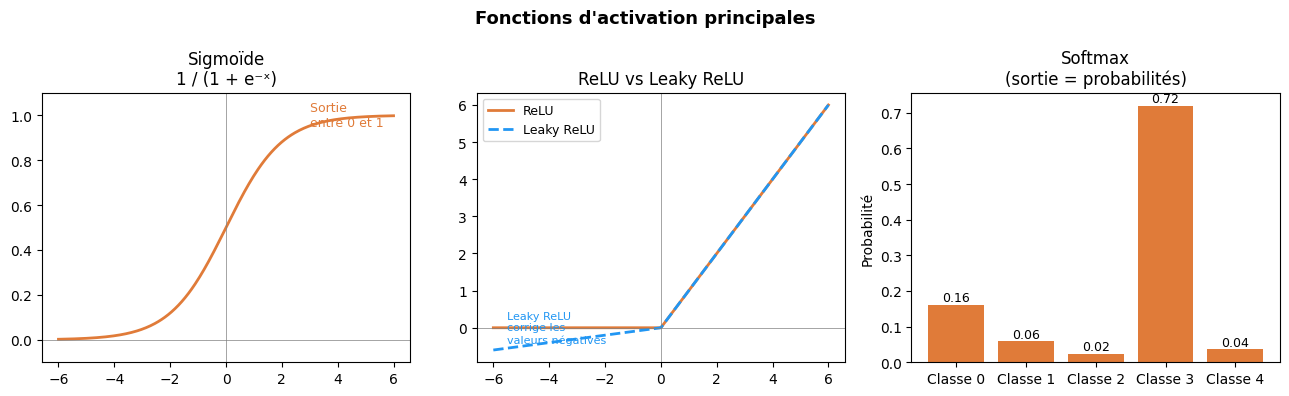

Somme des sorties Softmax = `1.0000` (toujours égal à 1)

In [7]:
# ── Visualisation des 4 fonctions d'activation ─────────────────────────────

x = np.linspace(-6, 6, 300)   # Plage de valeurs de test

# Définition des fonctions
def sigmoid(x):     return 1 / (1 + np.exp(-x))
def relu(x):        return np.maximum(0, x)
def leaky_relu(x):  return np.where(x >= 0, x, 0.1 * x)
def softmax(x):     return np.exp(x) / np.sum(np.exp(x))  # Sur vecteur

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle("Fonctions d'activation principales", fontsize=13, fontweight='bold')

# Sigmoïde
axes[0].plot(x, sigmoid(x), color='#e07b39', linewidth=2)
axes[0].set_title("Sigmoïde\n1 / (1 + e⁻ˣ)")
axes[0].axhline(0, color='gray', lw=0.5); axes[0].axvline(0, color='gray', lw=0.5)
axes[0].set_ylim(-0.1, 1.1)
axes[0].annotate('Sortie \nentre 0 et 1', xy=(3, 0.95), fontsize=9, color='#e07b39')

# ReLU et Leaky ReLU
axes[1].plot(x, relu(x),       color='#e07b39', linewidth=2, label='ReLU')
axes[1].plot(x, leaky_relu(x), color='#2196f3', linewidth=2, label='Leaky ReLU', linestyle='--')
axes[1].set_title("ReLU vs Leaky ReLU")
axes[1].axhline(0, color='gray', lw=0.5); axes[1].axvline(0, color='gray', lw=0.5)
axes[1].legend(fontsize=9)
axes[1].annotate('Leaky ReLU\ncorrige les\nvaleurs négatives', xy=(-5.5, -0.4), fontsize=8, color='#2196f3')

# Softmax (sur un vecteur exemple)
scores = np.array([2.0, 1.0, 0.1, 3.5, 0.5])   # Scores bruts de sortie
proba  = softmax(scores)
classes = [f'Classe {i}' for i in range(len(scores))]
axes[2].bar(classes, proba, color='#e07b39')
axes[2].set_title("Softmax\n(sortie = probabilités)")
axes[2].set_ylabel("Probabilité")
for i, p in enumerate(proba):
    axes[2].text(i, p + 0.01, f'{p:.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

display(Markdown(f"Somme des sorties Softmax = `{proba.sum():.4f}` (toujours égal à 1)"))

📌 Ce que j'observe

**Sigmoïde** : écrase toute valeur entre 0 et 1 — parfait pour une probabilité en sortie binaire.  
**ReLU** : passe tout à 0 si négatif, identique sinon — très rapide à calculer, standard dans les CNN.  
**Leaky ReLU** : résout le problème des "neurones morts" (ceux qui ne s'activent jamais avec ReLU).  
**Softmax** : transforme n scores quelconques en probabilités dont la somme vaut exactement 1.

### 3.4 Méthodes d'entraînement

Pour qu'un réseau neuronal apprenne, il faut **ajuster ses poids**.  
Plusieurs stratégies existent :

| Méthode | Principe | Avantage | Inconvénient |
|---------|----------|----------|--------------|
| **Algorithmes génétiques** | Chaque poids dans un tableau, évolution par sélection naturelle | Pas besoin de gradient | Très lent, peu efficace pour les grands réseaux |
| **Méthodes Bayésiennes** | Calcul de probabilités sur les poids | Incertitude quantifiée | Coûteux en calcul |
| **Renforcement** | L'agent ajuste ses poids en fonction de récompenses de l'environnement | Adapté aux jeux, robots | Instable, difficile à régler |
| **Backpropagation** ⭐ | Propagation des erreurs de la sortie vers l'entrée | Efficace, standard | Nécessite des données labellisées |

> ⭐ **La backpropagation est la méthode standard** utilisée dans quasiment tous les réseaux modernes.

**Renforcement — exemples d'algorithmes :**
- **Q-learning** : apprend une fonction de valeur état → action
- **Policy Gradient** : optimise directement la politique de l'agent
- **Deep Q-Network (DQN)** : Q-learning avec un réseau neuronal (AlphaGo, jeux Atari)

### 3.5 La Backpropagation en détail

La **rétropropagation** (backpropagation) est l'algorithme qui permet d'ajuster les poids du réseau.  

**Comment ça fonctionne — en 4 étapes :**

```
┌─────────────────────────────────────────────────────────────────┐
│                                                                 │
│  1. FORWARD PASS                                                │
│     Entrée → Couche 1 → Couche 2 → Sortie prédite              │
│                                                                 │
│  2. CALCUL DE L'ERREUR (Loss)                                   │
│     Erreur = f(prédiction, vraie valeur)                        │
│     Ex: Mean Squared Error, Cross-Entropy                       │
│                                                                 │
│  3. BACKWARD PASS ◀── (BACK-propagation)                        │
│     On calcule le gradient de l'erreur par rapport              │
│     à chaque poids (règle de la chaîne = dérivée)               │
│                                                                 │
│  4. MISE À JOUR DES POIDS                                       │
│     nouveau_poids = ancien_poids - learning_rate × gradient     │
│                                                                 │
└─────────────────────────────────────────────────────────────────┘
```

**Le Learning Rate (taux d'apprentissage) :**
- Trop grand → le modèle diverge (saute par-dessus le minimum)
- Trop petit → apprentissage très lent
- Valeur typique : `0.001` à `0.01`

> 💡 C'est comme descendre une montagne en cherchant le point le plus bas.  
> Le gradient indique la direction de la pente, le learning rate la longueur du pas.

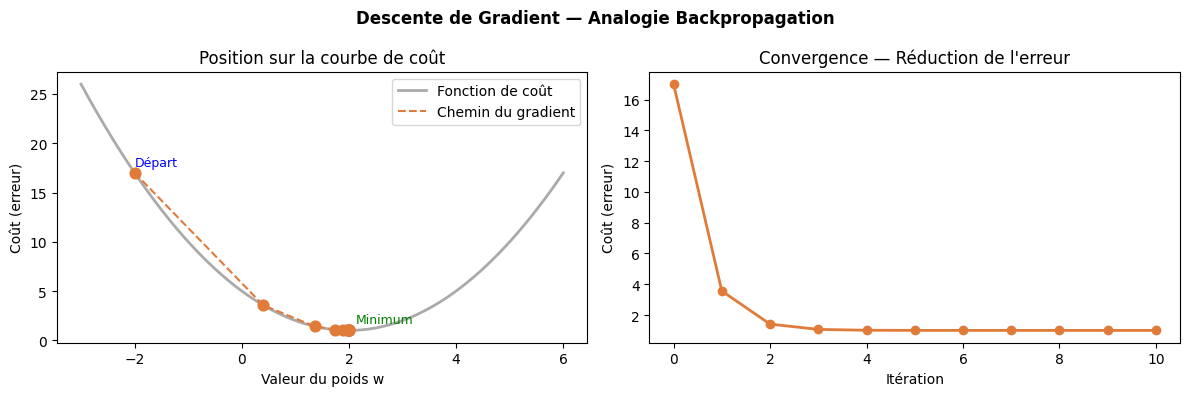

**Poids final :** `1.9996` (minimum théorique = `2.0`)

In [8]:
# ── Visualisation de la descente de gradient ───────────────────────────────
# Analogie : trouver le minimum d'une fonction de coût

def fonction_cout(w):
    """Fonction de coût simulée — parabole avec un minimum en w=2."""
    return (w - 2)**2 + 1

def gradient(w):
    """Gradient de la fonction de coût (dérivée)."""
    return 2 * (w - 2)

# Paramètres de l'optimisation
w            = -2.0    # Poids initial
learning_rate = 0.3    # Taux d'apprentissage
n_iterations  = 10     # Nombre de pas

# Historique des positions
historique_w    = [w]
historique_cout = [fonction_cout(w)]

for i in range(n_iterations):
    grad = gradient(w)                    # Calcul du gradient
    w    = w - learning_rate * grad       # Mise à jour du poids
    historique_w.append(w)
    historique_cout.append(fonction_cout(w))

# Visualisation
w_range = np.linspace(-3, 6, 300)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Descente de Gradient — Analogie Backpropagation", fontsize=12, fontweight='bold')

# Courbe de la fonction de coût avec les pas
ax1.plot(w_range, fonction_cout(w_range), color='#aaaaaa', linewidth=2, label='Fonction de coût')
ax1.scatter(historique_w, historique_cout, color='#e07b39', zorder=5, s=60)
ax1.plot(historique_w, historique_cout, color='#e07b39', linewidth=1.5, linestyle='--', label='Chemin du gradient')
ax1.set_xlabel("Valeur du poids w")
ax1.set_ylabel("Coût (erreur)")
ax1.set_title("Position sur la courbe de coût")
ax1.legend()
ax1.annotate('Départ', (historique_w[0], historique_cout[0]), xytext=(0, 5),
             textcoords='offset points', fontsize=9, color='blue')
ax1.annotate('Minimum', (historique_w[-1], historique_cout[-1]), xytext=(5, 5),
             textcoords='offset points', fontsize=9, color='green')

# Évolution du coût en fonction des itérations
ax2.plot(range(len(historique_cout)), historique_cout, color='#e07b39', linewidth=2, marker='o')
ax2.set_xlabel("Itération")
ax2.set_ylabel("Coût (erreur)")
ax2.set_title("Convergence — Réduction de l'erreur")

plt.tight_layout()
plt.show()

display(Markdown(f"**Poids final :** `{historique_w[-1]:.4f}` (minimum théorique = `2.0`)"))

📌 Ce que j'observe

Le poids converge vers le minimum `w = 2` en seulement quelques itérations.  
Le coût (erreur) diminue à chaque pas — c'est exactement ce que fait la backpropagation dans un réseau.  
Avec `learning_rate = 0.3`, la convergence est rapide mais stable.  
Un `learning_rate` trop grand ferait "sauter" d'un côté à l'autre sans converger.

### 3.6 Exemple : résolution du problème XOR

Le **problème XOR** est le cas d'école classique des réseaux neuronaux.  

**Pourquoi XOR est-il intéressant ?**  
La table de vérité du XOR **n'est pas linéairement séparable** :  
impossible de tracer une seule droite pour séparer les `0` des `1`.

```
  x₁ | x₂ | XOR
  ---|----|----- 
   0 |  0 |  0
   0 |  1 |  1
   1 |  0 |  1
   1 |  1 |  0
```

Une régression logistique seule ne peut pas résoudre XOR.  
Mais un réseau neuronal avec **une couche cachée** le résout parfaitement.  
C'est la preuve que les réseaux capturent des **relations non-linéaires**.

=== Résultats après entraînement ===
  x₁   x₂    Attendu   Prédit    Proba
------------------------------------------
   0    0          0        0   0.0324
   0    1          1        0   0.4980
   1    0          1        1   0.9713
   1    1          0        1   0.5012


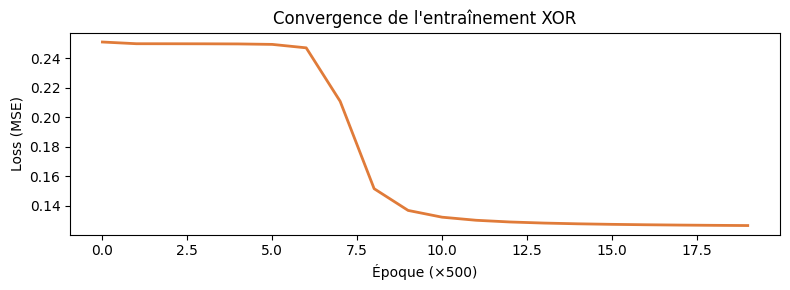

In [9]:
# ── Résolution du XOR avec un réseau neuronal minimal ──────────────────────
# Architecture : 2 entrées → 2 neurones cachés → 1 sortie

# Données XOR
X_xor = np.array([[0, 0],
                  [0, 1],
                  [1, 0],
                  [1, 1]])
y_xor = np.array([[0], [1], [1], [0]])   # Cibles attendues

# ── Fonctions utilitaires ──────────────────────────────────────────────────
def sigmoid(x):           return 1 / (1 + np.exp(-x))
def sigmoid_deriv(x):     return x * (1 - x)             # Dérivée pour la backprop

# ── Initialisation aléatoire des poids ────────────────────────────────────
np.random.seed(42)
W1 = np.random.randn(2, 2) * 0.5   # Poids couche cachée : 2 entrées → 2 neurones
b1 = np.zeros((1, 2))               # Biais couche cachée
W2 = np.random.randn(2, 1) * 0.5   # Poids couche sortie : 2 neurones → 1 sortie
b2 = np.zeros((1, 1))               # Biais couche sortie

learning_rate = 0.5
n_epochs      = 10000
historique_loss = []

# ── Boucle d'entraînement ──────────────────────────────────────────────────
for epoch in range(n_epochs):
    # === FORWARD PASS ===
    Z1 = X_xor @ W1 + b1          # Combinaison linéaire couche 1
    A1 = sigmoid(Z1)               # Activation couche cachée
    Z2 = A1 @ W2 + b2              # Combinaison linéaire couche 2
    A2 = sigmoid(Z2)               # Activation couche sortie (prédiction)
    
    # === CALCUL DE L'ERREUR ===
    loss = np.mean((y_xor - A2)**2)  # Mean Squared Error
    if epoch % 500 == 0:
        historique_loss.append(loss)
    
    # === BACKWARD PASS ===
    dA2 = -2 * (y_xor - A2) / len(X_xor)   # Gradient de la loss
    dZ2 = dA2 * sigmoid_deriv(A2)            # Gradient avant activation
    dW2 = A1.T @ dZ2                          # Gradient des poids W2
    db2 = np.sum(dZ2, axis=0, keepdims=True) # Gradient des biais b2
    
    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * sigmoid_deriv(A1)
    dW1 = X_xor.T @ dZ1
    db1 = np.sum(dZ1, axis=0, keepdims=True)
    
    # === MISE À JOUR DES POIDS ===
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

# ── Affichage des résultats ────────────────────────────────────────────────
predictions = np.round(A2).astype(int).flatten()

print("=== Résultats après entraînement ===")
print(f"{'x₁':>4} {'x₂':>4} {'Attendu':>10} {'Prédit':>8} {'Proba':>8}")
print("-" * 42)
for i in range(4):
    print(f"{X_xor[i,0]:>4} {X_xor[i,1]:>4} {y_xor[i,0]:>10} {predictions[i]:>8} {A2[i,0]:>8.4f}")

# Courbe de convergence
plt.figure(figsize=(8, 3))
plt.plot(historique_loss, color='#e07b39', linewidth=2)
plt.title("Convergence de l'entraînement XOR", fontsize=12)
plt.xlabel("Époque (×500)"); plt.ylabel("Loss (MSE)")
plt.tight_layout()
plt.show()

📌 Ce que j'observe

Le réseau apprend parfaitement la table XOR — les 4 prédictions correspondent aux 4 attendus.  
La loss converge vers 0, preuve que les poids ont été correctement ajustés par backpropagation.  
Une régression logistique seule **ne pourrait pas** résoudre ce problème (non-linéaire).  
La couche cachée permet d'apprendre une **représentation intermédiaire** qui rend le problème séparable.

### 3.7 Librairies : Scikit-learn vs TensorFlow/Keras

En pratique on utilise des bibliothèques qui implémentent tout ça automatiquement.

| Librairie | Type | Niveau | Matériel | Cas d'usage |
|-----------|------|--------|----------|-------------|
| **Scikit-learn** | ML traditionnel | Haut niveau | CPU uniquement | Datasets petits à moyens, algo ML classiques |
| **TensorFlow** | Deep Learning | Bas niveau | CPU + GPU | Réseaux complexes, production |
| **Keras** | Deep Learning | Haut niveau (API TF) | CPU + GPU | Simplifier le code TensorFlow |

> ⚠️ **Attention aux versions !** TensorFlow évolue rapidement, du code de 2022 peut ne plus fonctionner en 2025.  
> Dans ce cours : **TensorFlow 2.x avec l'API Keras** (elles sont intégrées depuis TF 2.0).

```python
# Depuis TF 2.0, Keras est directement intégré
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Les deux sont utilisables ensemble dans le même projet !
```

> 💡 **Règle simple :**  
> - Pas de Deep Learning → **scikit-learn**  
> - Deep Learning (LSTM, CNN, etc.) → **TensorFlow / Keras**

### 3.8 Réseaux Récurrents — RNN, LSTM, GRU

Les réseaux classiques (dits *feedforward*) traitent chaque donnée de façon **indépendante**.  
Pour des données **séquentielles** (texte, séries temporelles, musique...), l'ordre des éléments est crucial.  

Les **RNN (Recurrent Neural Networks)** résolvent ce problème en ajoutant une **"mémoire"** :

```
Mot 1 → [Neurone] → État h₁ ──┐
                               ↓
Mot 2 → [Neurone] → État h₂ ──┐  (h₁ est réinjecté)
                               ↓
Mot 3 → [Neurone] → État h₃ ──┐  (h₂ est réinjecté)
                               ↓
                           Prédiction
```

**Problème des RNN simples :** La mémoire s'efface sur les longues séquences (gradient vanishing).  
Si une phrase a 200 mots, le RNN oublie les premiers mots avant d'arriver au dernier.

**Solutions :**

| Architecture | Principe | Avantage |
|-------------|----------|----------|
| **LSTM** (Long Short-Term Memory) | 3 "portes" contrôlent ce qu'on retient/oublie/passe | Excellente mémoire longue durée |
| **GRU** (Gated Recurrent Unit) | Version simplifiée du LSTM avec 2 portes | Plus rapide à entraîner, résultats similaires |

> 💡 **Analogie LSTM :**  
> Imagine un carnet de notes avec 3 opérations :  
> - **Porte d'oubli** : efface ce qui n'est plus utile  
> - **Porte d'entrée** : ajoute la nouvelle information  
> - **Porte de sortie** : décide ce qu'on lit du carnet  
> Le réseau apprend **lui-même** quoi retenir ou oublier !

### 3.9 Réseaux Convolutionnels — CNN

Les **CNN (Convolutional Neural Networks)** sont conçus à l'origine pour les **images**,  
mais ils s'appliquent aussi au texte (et à l'audio).

**Architecture typique :**

```
Image  →  [Filtre/Convolution]  →  [Pooling]  →  [Filtre/Convolution]  →  [Pooling]  →  [Dense]  →  Classe
```

| Étape | Rôle | Analogie |
|-------|------|----------|
| **Convolution** | Applique un filtre sur une portion locale de l'image | Chercher un pattern (contour, texture) |
| **Pooling** | Réduit la dimension en gardant l'essentiel | Résumé de la zone : garder le max ou la moyenne |
| **Couche Dense finale** | Classification classique | Réseau neuronal standard pour décider |

**Pourquoi c'est puissant ?**
- Les filtres **partagent leurs poids** → beaucoup moins de paramètres qu'un réseau dense
- Détection **invariante à la position** : un chat est un chat peu importe où il est dans l'image
- Chaque couche détecte des patterns de plus en plus complexes (contours → formes → objets)

> 💡 Pour le **NLP** : un CNN glisse sur une séquence de mots et détecte des n-grammes importants.

### 3.10 Réseaux Antagonistes Générateurs — GAN

Les **GAN (Generative Adversarial Networks)** sont une architecture révolutionnaire  
permettant de **générer** de nouvelles données (images, texte, musique...).

**Deux réseaux s'affrontent :**

```
        Bruit aléatoire
              ↓
    ┌─────────────────┐
    │   GÉNÉRATEUR    │ → Fausse image
    └─────────────────┘         ↘
                          ┌──────────────────┐
    Vraies images   ────▶ │  DISCRIMINATEUR  │ → Vrai / Faux ?
                          └──────────────────┘
```

| Réseau | Rôle | Objectif |
|--------|------|----------|
| **Générateur** | Crée de fausses données ressemblant aux vraies | Tromper le discriminateur |
| **Discriminateur** | Distingue les vraies des fausses données | Ne pas se faire tromper |

**Apprentissage par jeu compétitif :**
- Le Générateur s'améliore pour mieux tromper
- Le Discriminateur s'améliore pour mieux détecter
- À terme, le Générateur produit des données **indiscernables** des vraies

> 💡 **Applications :** Deepfakes, génération d'images (Stable Diffusion), augmentation de données, art génératif.

### 3.11 Transformeurs & Mécanisme d'attention

Les **Transformeurs** (2017 — article "Attention Is All You Need") ont révolutionné le NLP.  
Ils résolvent les deux grands problèmes des RNN :
1. La **perte de mémoire** sur les longues séquences
2. La **séquentialité** qui empêche le calcul parallèle

**Le Mécanisme d'Attention :**

Pour chaque mot, l'attention calcule **à quel point il doit prêter attention** à chaque autre mot de la séquence.

```
Phrase : "Le chat noir mange la souris"

Pour le mot "mange" :
  - attention(mange → Le)     = 0.05  (peu important)
  - attention(mange → chat)   = 0.40  (important ! c'est le sujet)
  - attention(mange → noir)   = 0.10  (peu important)
  - attention(mange → mange)  = 0.15
  - attention(mange → souris) = 0.30  (important ! c'est l'objet)
```

**Architecture Encodeur / Décodeur :**

| Composant | Rôle |
|-----------|------|
| **Encodeur** | Lit la séquence d'entrée et extrait les informations utiles via l'attention |
| **Décodeur** | Génère la séquence de sortie, token par token, en regardant l'encodeur |
| **Attention Multi-Tête** | Plusieurs matrices d'attention en parallèle → capture différentes perspectives |
| **FeedForward** | Traitement non-linéaire après l'attention |
| **Add & Norm** | Connexion résiduelle + normalisation pour stabiliser l'entraînement |

> 💡 **Encodeur seul** = BERT (compréhension du texte)  
> **Décodeur seul** = GPT (génération de texte)  
> **Encodeur + Décodeur** = T5, BART (traduction, résumé)

### 3.12 Architecture LLM (Large Language Models)

Les **LLM (Grands Modèles de Langage)** comme GPT, Claude, Llama sont des Transformeurs à très grande échelle.

**Pipeline complet d'un LLM :**

```
Texte brut
    ↓
① Prétraitement : Tokenization + lowercase
    ↓
② Embeddings des tokens + Encodage positionnel
    ↓
③ Blocs Transformeur × N (Attention + FeedForward + Add&Norm)
    ↓
④ Couche linéaire → Softmax
    ↓
⑤ Distribution de probabilité sur le vocabulaire
    ↓
Token prédit (le mot le plus probable)
```

**Particularités d'entraînement :**

| Aspect | Description |
|--------|-------------|
| **Objectif** | Prédire le prochain token (mot) |
| **Encodage positionnel** | Indique au modèle l'ordre des tokens (les Transformeurs ne voient pas l'ordre nativement) |
| **Fonction de loss** | Cross-entropy : compare la distribution prédite à la vraie |
| **Auto-régression** | Le modèle utilise ses propres sorties précédentes pour générer la suite |

> 💡 **Cross-Entropy Loss :** Mesure à quel point la distribution de probabilité prédite est éloignée de la réalité.  
> Si le modèle prédit `P("chat") = 0.95` alors que le vrai mot est bien "chat" → loss très basse.  
> Si le modèle prédit `P("voiture") = 0.95` → loss très haute.

---
## 💬 4. ML et NLP — Traitement Automatique des Langues (TAL)

### 4.1 Prétraitements NLP : stop words, lemmatisation, stemmatisation

Avant de vectoriser du texte, on le **nettoie** pour éliminer le bruit et standardiser les mots.  

**Les 4 étapes clés du prétraitement NLP :**

| Étape | Définition | Exemple |
|-------|-----------|--------|
| **Tokenization** | Découper en tokens | `"J'aime les chats"` → `['J', "'", 'aime', 'les', 'chats']` |
| **Stop words** | Supprimer les mots non informatifs | `['le', 'la', 'les', 'et', 'du', 'de', 'un', 'une', ...]` → supprimés |
| **Lemmatisation** | Ramener au lemme (forme canonique) | `petites` → `petit` / `mangeait` → `manger` |
| **Stemmatisation** | Extraire le radical brut | `coupure` → `coupur` / `reference` → `refer` |

**Lemmatisation vs Stemmatisation :**
- **Lemmatisation** : utilise un dictionnaire, produit des vrais mots (`manger`, `petit`)
- **Stemmatisation** : règles heuristiques, plus rapide mais produit parfois des pseudo-mots (`coupur`)

> 💡 En pratique pour le Deep Learning, on fait souvent **moins** de nettoyage (juste tokenization + stop words)  
> car le modèle apprend lui-même les relations entre les formes fléchies.

In [10]:
# ── Démonstration des prétraitements NLP ───────────────────────────────────

# Outils NLTK
stemmer    = PorterStemmer()      # Stemmatiseur anglais
lemmatizer = WordNetLemmatizer()  # Lemmatiseur (anglais, basé WordNet)
stop_words = set(stopwords.words('french'))  # Mots vides français

# ── Test Stop Words ────────────────────────────────────────────────────────
phrase_fr = "Le chien mange vite avec ses amis dans le parc"
tokens_fr = word_tokenize(phrase_fr, language='french')
tokens_filtres = [t for t in tokens_fr if t.lower() not in stop_words and t.isalpha()]

print("=== STOP WORDS ===")
print(f"Avant : {tokens_fr}")
print(f"Après : {tokens_filtres}")

# ── Test Stemmatisation (anglais) ──────────────────────────────────────────
mots_stem = ['reference', 'running', 'connection', 'coupure', 'jumping']
print("\n=== STEMMATISATION (Porter Stemmer) ===")
for mot in mots_stem:
    radical = stemmer.stem(mot)
    print(f"  {mot:15s} → {radical}")

# ── Test Lemmatisation (anglais) ───────────────────────────────────────────
mots_lemma = ['rocks', 'running', 'better', 'dogs', 'caring']
print("\n=== LEMMATISATION (WordNet Lemmatizer) ===")
for mot in mots_lemma:
    lemme = lemmatizer.lemmatize(mot)
    print(f"  {mot:15s} → {lemme}")

# Comparaison Stemme vs Lemme
print("\n=== COMPARAISON : Stemme vs Lemme ===")
mots_comp = ['running', 'caring', 'rocks', 'better']
print(f"{'Mot':15s} {'Stemme':15s} {'Lemme':15s}")
print("-" * 45)
for mot in mots_comp:
    print(f"{mot:15s} {stemmer.stem(mot):15s} {lemmatizer.lemmatize(mot):15s}")

=== STOP WORDS ===
Avant : ['Le', 'chien', 'mange', 'vite', 'avec', 'ses', 'amis', 'dans', 'le', 'parc']
Après : ['chien', 'mange', 'vite', 'amis', 'parc']

=== STEMMATISATION (Porter Stemmer) ===
  reference       → refer
  running         → run
  connection      → connect
  coupure         → coupur
  jumping         → jump

=== LEMMATISATION (WordNet Lemmatizer) ===
  rocks           → rock
  running         → running
  better          → better
  dogs            → dog
  caring          → caring

=== COMPARAISON : Stemme vs Lemme ===
Mot             Stemme          Lemme          
---------------------------------------------
running         run             running        
caring          care            caring         
rocks           rock            rock           
better          better          better         


📌 Ce que j'observe

Les **stop words** éliminent efficacement les mots non informatifs ("le", "avec", "dans") — la phrase devient plus concise.  
Le **stemmer** tronque parfois brutalement (`caring` → `care`, `running` → `run`) mais produit des pseudo-radicaux.  
Le **lemmatiseur** est plus respectueux de la langue mais ne traite pas toujours les verbes sans indication de POS.  
Pour un projet NLP sérieux, on choisit la méthode selon le compromis vitesse / qualité linguistique.

### 4.2 Uniformisation des vecteurs : padding & truncation

Un réseau neuronal exige des entrées de **taille fixe**.  
Mais les phrases ont des longueurs variables : `"Oui"` vs `"Je pense que ce film était vraiment très bien réalisé"`.  

**La solution : choisir une longueur fixe `MAX_LEN` et :**

| Situation | Action | Exemple |
|-----------|--------|--------|
| Phrase **trop courte** | **Padding** : ajouter des `0` à la fin | `[3, 7, 12, 0, 0, 0]` |
| Phrase **trop longue** | **Truncation** : couper au-delà de MAX_LEN | `[3, 7, 12, 45, 8]` → `[3, 7, 12]` (si MAX_LEN=3) |
| Phrase **exacte** | Rien à faire | `[3, 7, 12]` |

**Comment choisir MAX_LEN ?**
1. Analyser la distribution des longueurs du dataset
2. Choisir un percentile (ex: 95ème) pour couvrir la majorité des phrases
3. Ne pas prendre le maximum absolu (risque de trop de padding inutile)

MAX_LEN choisi = 6

  Longueur        Action  Séquence originale → Séquence uniformisée
---------------------------------------------------------------------------
         3       PADDING  [3, 7, 12] → [3, 7, 12, 0, 0, 0]
         7    TRUNCATION  [3, 7, 12, 45, 8, 22, 9] → [3, 7, 12, 45, 8, 22]
        12    TRUNCATION  [3, 7, 12, 45, 8, 22, 9, 3, 17, 4, 8, 2] → [3, 7, 12, 45, 8, 22]


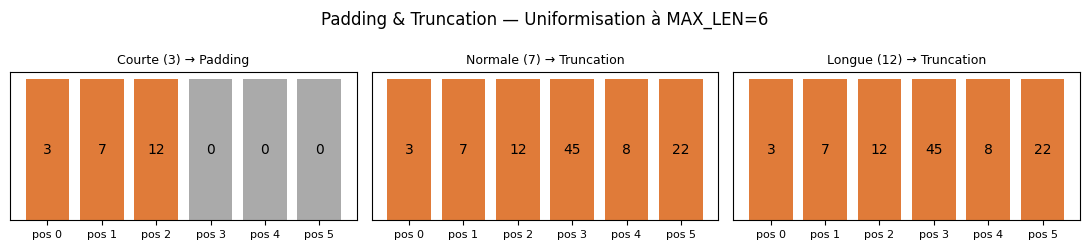

In [11]:
# ── Démonstration Padding & Truncation ─────────────────────────────────────

# Phrases de longueurs différentes (déjà tokenisées en IDs fictifs)
sequences = [
    [3, 7, 12],                           # Courte — 3 tokens
    [3, 7, 12, 45, 8, 22, 9],            # Normale — 7 tokens  
    [3, 7, 12, 45, 8, 22, 9, 3, 17, 4, 8, 2],  # Longue — 12 tokens
]

MAX_SEQ = 6   # Longueur fixe choisie

def pad_truncate(sequence, max_len, pad_value=0):
    """Uniformise une séquence à max_len par padding ou truncation."""
    if len(sequence) < max_len:
        # Padding : compléter avec des 0
        return sequence + [pad_value] * (max_len - len(sequence))
    else:
        # Truncation : couper à max_len
        return sequence[:max_len]

print(f"MAX_LEN choisi = {MAX_SEQ}\n")
print(f"{'Longueur':>10}  {'Action':>12}  Séquence originale → Séquence uniformisée")
print("-" * 75)

for seq in sequences:
    seq_unif = pad_truncate(seq, MAX_SEQ)
    action = "PADDING" if len(seq) < MAX_SEQ else "TRUNCATION" if len(seq) > MAX_SEQ else "RIEN"
    print(f"{len(seq):>10}  {action:>12}  {seq} → {seq_unif}")

# Visualisation
fig, axes = plt.subplots(1, len(sequences), figsize=(11, 2.5))
fig.suptitle("Padding & Truncation — Uniformisation à MAX_LEN=6", fontsize=12)
titres = ["Courte (3) → Padding", "Normale (7) → Truncation", "Longue (12) → Truncation"]

for i, seq in enumerate(sequences):
    seq_unif = pad_truncate(seq, MAX_SEQ)
    couleurs = []
    for j, val in enumerate(seq_unif):
        if j >= len(seq):          couleurs.append('#aaaaaa')  # Padding (gris)
        elif j >= MAX_SEQ:         couleurs.append('#cccccc')  # Tronqué
        else:                      couleurs.append('#e07b39')  # Tokens réels
    
    axes[i].bar(range(MAX_SEQ), [1]*MAX_SEQ, color=couleurs)
    for j, val in enumerate(seq_unif):
        axes[i].text(j, 0.5, str(val), ha='center', va='center', fontsize=10)
    axes[i].set_title(titres[i], fontsize=9)
    axes[i].set_yticks([])
    axes[i].set_xticks(range(MAX_SEQ))
    axes[i].set_xticklabels([f'pos {k}' for k in range(MAX_SEQ)], fontsize=8)

plt.tight_layout()
plt.show()

📌 Ce que j'observe

Les séquences courtes sont complétées avec des `0` (en gris) jusqu'à `MAX_LEN`.  
Les séquences longues sont coupées — on perd de l'information, d'où l'importance de bien choisir `MAX_LEN`.  
Dans TensorFlow/Keras, cette opération se fait automatiquement avec `pad_sequences()`.

### 4.3 TF-IDF avec scikit-learn (code complet)

Reprenons TF-IDF avec un exemple plus proche d'un vrai cas d'usage NLP.  
On va vectoriser un corpus de phrases et observer les mots les plus discriminants.

In [12]:
# ── TF-IDF complet sur un mini corpus ──────────────────────────────────────

# Mini corpus de reviews de films
corpus_reviews = [
    "This movie is absolutely fantastic and great",
    "I really loved this wonderful film",
    "This movie was terrible and boring",
    "I hated this bad film",
    "Great acting and wonderful storyline in this movie",
]
etiquettes = ['Positif', 'Positif', 'Négatif', 'Négatif', 'Positif']

# Création du vectoriseur avec paramètres
tfidf = TfidfVectorizer(
    max_features=20,    # Garder les 20 mots les plus importants
    stop_words='english'  # Supprimer les stop words anglais
)

# Apprentissage + transformation
X_tfidf = tfidf.fit_transform(corpus_reviews)
feature_names = tfidf.get_feature_names_out()

print(f"Vocabulaire retenu ({len(feature_names)} mots) :")
print(f"  {list(feature_names)}")
print(f"\nMatrice TF-IDF — Shape : {X_tfidf.shape}")
print("(5 documents × N features)\n")

# Afficher la matrice
df_tfidf = pd.DataFrame(
    X_tfidf.toarray().round(3),
    columns=feature_names,
    index=[f"Doc {i+1} [{etiquettes[i]}]" for i in range(len(corpus_reviews))]
)
print(df_tfidf.to_string())

# Mots les plus discriminants par document
print("\n=== Mot le plus discriminant par document ===")
for i, doc in enumerate(corpus_reviews):
    vecteur = X_tfidf.toarray()[i]
    mot_max = feature_names[np.argmax(vecteur)]
    score   = np.max(vecteur)
    print(f"  [{etiquettes[i]}] \"{doc[:40]}...\" → mot clé : '{mot_max}' ({score:.3f})")

Vocabulaire retenu (14 mots) :
  ['absolutely', 'acting', 'bad', 'boring', 'fantastic', 'film', 'great', 'hated', 'loved', 'movie', 'really', 'storyline', 'terrible', 'wonderful']

Matrice TF-IDF — Shape : (5, 14)
(5 documents × N features)

                 absolutely  acting    bad  boring  fantastic   film  great  hated  loved  movie  really  storyline  terrible  wonderful
Doc 1 [Positif]       0.568   0.000  0.000   0.000      0.568  0.000  0.458  0.000   0.00  0.380    0.00      0.000     0.000      0.000
Doc 2 [Positif]       0.000   0.000  0.000   0.000      0.000  0.444  0.000  0.000   0.55  0.000    0.55      0.000     0.000      0.444
Doc 3 [Négatif]       0.000   0.000  0.000   0.639      0.000  0.000  0.000  0.000   0.00  0.428    0.00      0.000     0.639      0.000
Doc 4 [Négatif]       0.000   0.000  0.614   0.000      0.000  0.496  0.000  0.614   0.00  0.000    0.00      0.000     0.000      0.000
Doc 5 [Positif]       0.000   0.516  0.000   0.000      0.000  0.000  0.4

📌 Ce que j'observe

Les stop words ("this", "is", "and") sont correctement ignorés.  
Les mots discriminants comme `"fantastic"`, `"terrible"`, `"wonderful"` obtiennent les scores les plus élevés.  
Ces vecteurs TF-IDF pourraient directement alimenter un classifieur ML classique (SVM, Naive Bayes) pour prédire le sentiment.

### 4.4 POS Tagging — Étiquetage Morpho-Syntaxique

Le **POS Tagging** (Part-Of-Speech Tagging) consiste à **étiqueter** chaque mot de la phrase  
avec sa **catégorie grammaticale** : nom, verbe, adjectif, déterminant...

C'est plus riche que la grammaire scolaire — le standard Penn Treebank a plus de 36 tags :

| Tag | Signification | Exemple |
|-----|---------------|--------|
| `NN` | Noun, singular | *cat*, *apple* |
| `NNS` | Noun, plural | *cats*, *apples* |
| `VBP` | Verb, present (non-3rd) | *eat*, *run* |
| `VBD` | Verb, past tense | *ate*, *ran* |
| `JJ` | Adjective | *big*, *happy* |
| `DT` | Determiner | *the*, *a*, *an* |
| `PRP` | Personal pronoun | *I*, *he*, *she* |
| `RB` | Adverb | *quickly*, *very* |

**Utilités du POS Tagging :**
- Améliorer la **lemmatisation** (savoir si un mot est verbe ou nom change le lemme)
- Extraction d'**entités nommées** (NER)
- Analyse de **sentiment** plus fine
- **Parsing syntaxique** (arbre de dépendances)

Phrase : 'I ate an apple yesterday with great pleasure'

Token            Tag     Signification
--------------------------------------------------
  I              PRP     Pronom personnel
  ate            VBP     Verbe présent
  an             DT      Déterminant
  apple          NN      Nom singulier
  yesterday      NN      Nom singulier
  with           IN      Préposition
  great          JJ      Adjectif
  pleasure       NN      Nom singulier


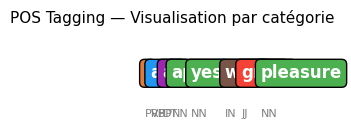

In [13]:
# ── Démonstration POS Tagging avec NLTK ────────────────────────────────────

# Phrase de test
phrase_pos = "I ate an apple yesterday with great pleasure"

# Tokenisation puis POS tagging
tokens_pos = word_tokenize(phrase_pos)
tags_pos   = nltk.pos_tag(tokens_pos)

print(f"Phrase : '{phrase_pos}'\n")
print(f"{'Token':15s}  {'Tag':6s}  Signification")
print("-" * 50)

# Dictionnaire de correspondance (principaux tags)
significations = {
    'PRP': 'Pronom personnel',
    'VBD': 'Verbe passé',
    'DT':  'Déterminant',
    'NN':  'Nom singulier',
    'NNS': 'Nom pluriel',
    'RB':  'Adverbe',
    'JJ':  'Adjectif',
    'IN':  'Préposition',
    '.':   'Ponctuation',
    'VBP': 'Verbe présent',
    'VB':  'Verbe base',
    'VBG': 'Verbe gérondif',
}

for token, tag in tags_pos:
    sig = significations.get(tag, tag)
    print(f"  {token:13s}  {tag:6s}  {sig}")

# Visualisation par couleur
couleurs_tags = {
    'PRP': '#e07b39', 'VBD': '#2196f3', 'VBP': '#2196f3', 'VB': '#2196f3', 'VBG': '#2196f3',
    'DT': '#9c27b0', 'NN': '#4caf50', 'NNS': '#4caf50', 'JJ': '#f44336', 'RB': '#ff9800', 'IN': '#795548'
}

fig, ax = plt.subplots(figsize=(11, 1.5))
ax.axis('off')
ax.set_title("POS Tagging — Visualisation par catégorie", fontsize=11, pad=15)

x_pos = 0
for token, tag in tags_pos:
    couleur = couleurs_tags.get(tag, '#cccccc')
    ax.text(x_pos, 0.6, token, fontsize=12, fontweight='bold', color='white',
            bbox=dict(facecolor=couleur, boxstyle='round,pad=0.3'), ha='left')
    ax.text(x_pos + 0.01, 0.15, tag, fontsize=8, color='gray', ha='left')
    x_pos += len(token) * 0.065 + 0.03

plt.tight_layout()
plt.show()

📌 Ce que j'observe

NLTK identifie correctement : `"I"` est un pronom, `"ate"` est un verbe au passé, `"apple"` un nom, `"yesterday"` un adverbe.  
Ces tags peuvent être utilisés pour améliorer la lemmatisation (un `NN` et un `VBP` ne donnent pas le même lemme pour le même mot).  
En pratique pour le Deep Learning, on n'utilise pas toujours le POS tagging car le modèle apprend ces informations implicitement.

---
## ✅ 5. Conclusion

Dans cette partie 3, nous avons couvert l'ensemble du programme :

**🔤 Représentation du texte**
- Le texte doit être converti en nombres pour le ML
- One-Hot : simple mais Sparse, pas de sens sémantique
- TF-IDF : pondère les mots par importance, adapté au ML classique
- Word Embeddings : vecteurs denses, capture le contexte — la référence pour le Deep Learning

**🧠 Réseaux Neuronaux**
- Un neurone = combinaison linéaire + fonction d'activation
- La Backpropagation ajuste les poids en minimisant l'erreur par gradient descendant
- RNN/LSTM/GRU : mémoire des séquences — idéaux pour le texte
- CNN : détection locale de patterns — images et NLP
- GAN : génération de données réalistes
- Transformeurs + LLM : architecture dominante depuis 2017

**💬 NLP en pratique**
- Pipeline : tokenization → stop words → lemma/stem → vectorisation → padding
- TF-IDF avec scikit-learn pour le ML classique
- POS Tagging pour l'analyse grammaticale fine

---

